

 **Apprentissage Supervisé- Regression**

* Classification si les étiquettes sont des valeur discrètes

* Régression  si les étiquettes sont des valeurs continues (par exemple réels)





In [1]:
# import des bibliothèques Python utiles:
import numpy as np
import matplotlib.pyplot as plt

# "magic function" Jupyter pour l'affichage des graphiques dans le carnet:
%matplotlib inline



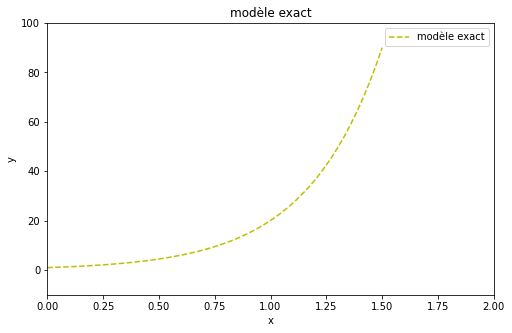

In [3]:
#Nous générons les données  et les étiquettes associées  par des fonctions mathématiques.

# nous supposons que le modèle  suit le modèle suivant

x_mod = np.linspace(0., 1.5, 150)

y_m = np.exp(3*x_mod)

# Dessiner le modèle exact 
plt.figure(figsize=(8,5))
plt.plot(x_mod, y_m, '--y')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('modèle exact')
plt.legend(["modèle exact"]);  

Changez la taille de X_m pour que les données soient un tableau où chaque élément est un tableau (une matrice)

Affichez 3 premières données et les étiquettes associées.

In [4]:
X_m = x_mod.reshape(len(x_mod),1)

#X_m = x_mod[:,np.newaxis]


#print("shape{}".format(X_m.shape))

print(X_m[:3])

[[0.        ]
 [0.01006711]
 [0.02013423]]


In [5]:
"""Nous générons  maintenant les données que l'on va utiliser 
pour faire l'apprentissage  en ajoutant du bruit aléatoire 
(qui suit la loi normale)
"""


x_data = np.array([0, .1, .2, .5, .8, .9, 1, 1.2, 1.5])

#nous changeons la taille de données pour pouvoir utiliser dans ScikitLearn
X_d = x_data.reshape(len(x_data),1) 


np.random.seed(44)
y_d = np.exp(3*X_d) + 5.0 * np.random.randn(len(X_d),1)

#y_d sont les étiquettes pour les données X_d

print("données X_d:")
print(X_d)
print("données y_d:")
print(y_d)

print("données exactes:")
y_m = np.exp(3*X_d)
print(y_m)

données X_d:
[[0. ]
 [0.1]
 [0.2]
 [0.5]
 [0.8]
 [0.9]
 [1. ]
 [1.2]
 [1.5]]
données y_d:
[[-2.75307359]
 [ 7.93164543]
 [ 8.05281894]
 [-3.54288964]
 [ 3.68245799]
 [ 6.30437944]
 [29.37945538]
 [37.03617433]
 [89.75552032]]
données exactes:
[[ 1.        ]
 [ 1.34985881]
 [ 1.8221188 ]
 [ 4.48168907]
 [11.02317638]
 [14.87973172]
 [20.08553692]
 [36.59823444]
 [90.0171313 ]]


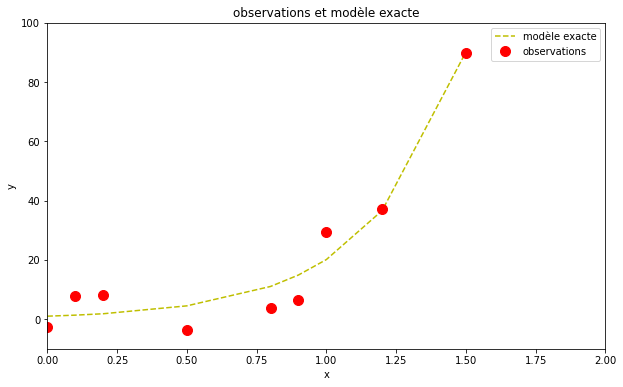

In [7]:
#Dessinez le modèle génératif (exact) et les données observées (X_d) dans la même courbe

plt.figure(figsize=(10,6))
plt.plot(X_d, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations et modèle exacte')
plt.legend(["modèle exacte","observations"]);  


Faites l'apprentissage sur les X_d (observations) par la méthode LinearRegression

 
Cette méthode consiste à trouver une fonction linéaire:

 $y_d = a X_d + b$

a : pente  (coef_ pour     scikitLearn)

b : coordonné à l'origine (intercept_ pour     scikitLearn)



La méthode  consisté à minimiser la fonction de coût:

$$ \sum_{i=1}^m (a X_d[i]+b - y_d[i])^2 $$

sur l'ensemble d'observation $i=1, \cdots m$.

Les données  de notre exemple sont 9 couples de 
$$(X_d[i],y_d[i])$$

In [8]:
# On importe le modèle  
import sklearn.linear_model as lm

# On crée un objet scikit-learn pour la régression linéaire:
lr = lm.LinearRegression()

# On fait l'apprentissage pour trouver  les paramètres a et b: 
lr.fit(X_d, y_d)  

# de manière générale, la méthode fit permet l'apprentissage des paramètres du modèle 
# (ici par la méthodes des moindres carrés), qui sont stockés dans les attributs suivants:

b = lr.intercept_
a = lr.coef_


print(" b: {}".format(b)) 
print(" a: {}".format(a))




 b: [-11.13423665]
 a: [[44.52493846]]


Dessinez  la courbe  a X_m +b 

C'est le modèle que vous avez obtenu en faisant l'apprentissage  sur les données x_data

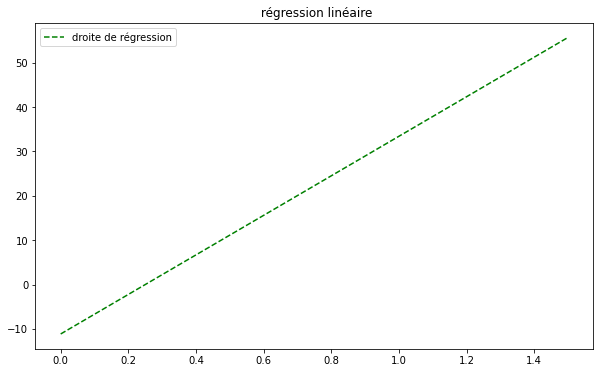

In [9]:
# représentation graphique:
y_l = [ a[0,0]*x +b for x in x_mod]


plt.figure(figsize=(10,6))
plt.plot(x_mod, y_l, '--g')

plt.title(' régression linéaire')
plt.legend(["droite de régression"]);
#plt.show()



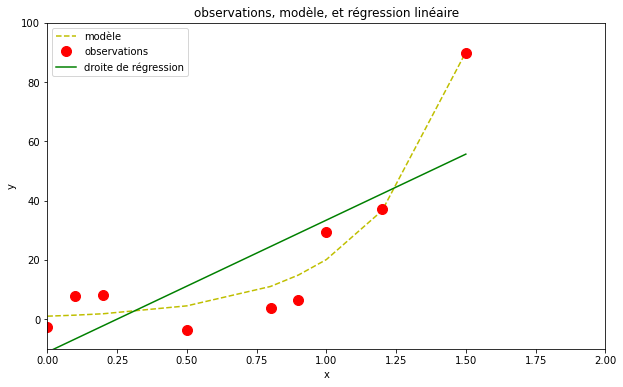

In [10]:

# La méthode predict permet de prédire les valeurs y pour les x passés en argument


# On prédit des valeurs de y pour les x entre 0 et 1.5

y_pred_lr = lr.predict(X_m)  

# On dessine sur la même courbe, le modèle (X_m), les observations(X_d) et le modèle
#obtenu par l'apprentissage (droite de regression)


plt.figure(figsize=(10,6))
plt.plot(X_d, y_m, '--y')
plt.plot(X_d, y_d, 'or', ms=10)
plt.plot(X_m, y_pred_lr, '-g')
plt.xlim(0, 2.0)
plt.xlabel("x")
plt.ylim(-10, 100)
plt.ylabel("y")
plt.title('observations, modèle, et régression linéaire')
plt.legend(["modèle","observations","droite de régression"]);
plt.show()



Que constatez-vous? La droite de regression présente bien le modèle ou non?




In [11]:
# Nous calculons la fiabilité du modèle de regréssion
# Nous importons les modules 

from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score 


**R2 Score**

https://scikit-learn.org/stable/modules/model_evaluation.html#r2-score

Exemples:

In [12]:
from sklearn.metrics import r2_score

y_true = [1, 2, 3]
y_pred = [1, 2, 3]
r2_score(y_true, y_pred)

#Meilleur score

1.0

In [13]:
y_true = [1, 2, 3]
y_pred = [2, 2, 2]
r2_score(y_true, y_pred)
#le résultat est le m^me peu importe l'entrée et c'est la valeur moyenne

0.0

In [14]:
y_true = [1, 2, 3]
y_pred = [3, 2, 1]
r2_score(y_true, y_pred)
#négatif  très mauvais

-3.0

**Mean_squared Erreur**

https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error

Exemples

In [15]:
from sklearn.metrics import mean_squared_error
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]
mean_squared_error(y_true, y_pred)

0.375

In [16]:
y_true = [1, 2, 3]
y_pred = [1, 2, 3]
mean_squared_error(y_true, y_pred)


0.0

In [17]:
y_true = [1, 2, 3]
y_pred = [2, 2, 2]
mean_squared_error(y_true, y_pred)
#le résultat est le m^me peu importe l'entrée et c'est la valeur moyenne


0.6666666666666666

In [18]:
y_true = [1, 2, 3]
y_pred = [3, 2, 1]
mean_squared_error(y_true, y_pred)

2.6666666666666665

In [19]:
#Calculez  (mean_squared_error) erreur
print("MSE LM pour X_d= {} ".format(mean_squared_error(y_d,lr.predict(X_d))))

#Calculez r2score  pour les observations
print("r2score  LM pour X_d = {} ".format(r2_score(y_d,lr.predict(X_d))))

#par défaut score c'est r2
#Attention au paramètres 
print("par défault c'est r2 {}".format(lr.score(X_d,y_d)))

MSE LM pour X_d= 306.28291568038844 
r2score  LM pour X_d = 0.609349830405603 
par défault c'est r2 0.609349830405603


Calculez les scores que nous obtenons si on estime les étiquettes à partir du modèle pour les données X_m 


In [20]:
print(X_m.shape)
y_m = np.exp(3*x_mod)
print (y_m.shape)
lr.fit(X_m, y_m)  

print("MSE LM pour X_m ={} ".format(mean_squared_error(y_m,lr.predict(X_m))))


print("r2score LM pour X_m ={} ".format(r2_score(y_m, lr.predict(X_m))))

print("par défault c'est r2 {}".format(lr.score(X_m, y_m)))

(150, 1)
(150,)
MSE LM pour X_m =121.0791235873534 
r2score LM pour X_m =0.7686370379425808 
par défault c'est r2 0.7686370379425808


On constate que si on prend en compte toutes les données (X_m) les scores 
sont meilleurs par rapport à ceux qu'on trouve si on  ne considère que  les données observés (X_d)



**La méthode n'est pas limitée à une seule propriété (features). Il peut y avoir plusieurs propriétés(voir TP)**